In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:85% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

**<font size="10" color="red">ch01.NLTK자연어처리 패키지</font>**
# 1. 자연어처리
- 자연어 : 일상적인 언어
- 자연어 처리 분야
    * 탐색(이해) : 형태소 분석 ->pos tagging(품사태깅)->의미분석 또는 시각화
    * 모델생성 : RNN, LSTM, GRU, seq2seq, transformer
    
# 2. 자연어 처리 절차
- 분석 후보 생성 : 형태소 분리, 품사태깅
- 제약조건 : 규칙확인 및 불용어 처리
- 분석 : 시각화(워드클라우드, plot), 유사도분석, 연관분석, RNN,LSTM,GRU,seq2seq,transformer

# 3. 한글 형태소 분석 엔진(Konlpy..)
    - 공통기능 : mrphs(형태소 나누기), pos(형태소로 나누어 품사태그), nouns(명사추출)
- Konlpy (pip install konlpy) : konlpy.org -> API->
    * HanNanum : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * Kkma     : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * Komoran  : 자바로 만든 형태소 분석기(JAVA_HOME 시스템 환경변수, path설정)
    * okt(Twitter)      
- Mecap(pip install python-mecab-ko)
    * MeCab : C++로 만든 형태소 분석기. 저사양환경에서 사용가능. 다국어 바인딩 지원
- Konlp : R용 자연어 처리기

In [1]:
import os
os.environ.get('JAVA_HOME')

'C:\\Program Files\\Java\\jdk-17'

In [2]:
import konlpy
konlpy.__version__

'0.6.0'

## 3.1 HanNanum

In [3]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로 
많이 사용되는 언어입니다.
'''

In [5]:
from konlpy.tag import Hannanum
hannanum = Hannanum(jvmpath = None,
                   max_heap_size=512) # 기본값:1024,
hannanum.analyze(text) # text를 세밀하게 분석해서, 형태소, 품사를 반환(ntag=69로 형태소 분석)

[[[('아름답', 'paa'), ('지만', 'ecs')],
  [('아름답', 'paa'), ('지', 'ecs'), ('만', 'jxc')],
  [('아름답', 'paa'), ('지', 'ecx'), ('말', 'px'), ('ㄴ', 'etm')]],
 [[('다소', 'mag')], [('다소', 'ncn')]],
 [[('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncn'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'jxc')],
  [('복잡', 'ncps'), ('하기', 'ncn'), ('도', 'ncn')],
  [('복잡', 'ncps'), ('하', 'xsms'), ('기', 'etn'), ('도', 'jxc')]],
 [[('하', 'pvg'), ('ㄴ', 'etm')],
  [('한', 'nnc')],
  [('한', 'ncn')],
  [('한', 'nbn')],
  [('하', 'px'), ('ㄴ', 'etm')]],
 [[('한국어', 'ncn'), ('는', 'jxc')]],
 [[('전세계', 'ncn'), ('에서', 'jca')],
  [('전세', 'ncn'), ('계', 'ncn'), ('에서', 'jca')],
  [('전', 'xp'), ('세계', 'ncn'), ('에서', 'jca')]],
 [[('13', 'nnc'), ('번', 'nbu'), ('째', 'xsnu'), ('로', 'jca')]],
 [],
 [[('많', 'paa'), ('이', 'xsa')], [('많이', 'mag')]],
 [[('사용', 'ncpa'), ('되', 'xsvn'), ('는', 'etm')]],
 [[('언어', 'ncn'), ('이', 'jp'), ('ㅂ니다', 'ef')]],
 [[('.', 'sf')], [('.', 'sy')]]]

- Korean POS tags comparison chart.xlsx 다운로드:

In [6]:
# 형태소 분석 : morphs
print(hannanum.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '하', 'ㄴ', '한국어', '는', '전세계', '에서', '13번', '째', '로', '많', '이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [7]:
# 명사만 추출 : nouns
print(hannanum.nouns(text))

['복잡', '한국어', '전세계', '13번', '사용', '언어']


In [8]:
# 품사태깅 : pos
print(hannanum.pos(text, ntags=22))

[('아름답', 'PA'), ('지만', 'EC'), ('다소', 'MA'), ('복잡', 'NC'), ('하', 'XS'), ('기', 'ET'), ('도', 'JX'), ('하', 'PV'), ('ㄴ', 'ET'), ('한국어', 'NC'), ('는', 'JX'), ('전세계', 'NC'), ('에서', 'JC'), ('13', 'NN'), ('번', 'NB'), ('째', 'XS'), ('로', 'JC'), ('많', 'PA'), ('이', 'XS'), ('사용', 'NC'), ('되', 'XS'), ('는', 'ET'), ('언어', 'NC'), ('이', 'JP'), ('ㅂ니다', 'EF'), ('.', 'SF')]


In [9]:
# ex1. text에서 형용사(PA)만 추출
tagged_text = hannanum.pos(text, ntags=22)
# words = []
# for token, tag in tagged_text:
#     if tag == 'PA':
#         words.append(token)
words = [token for token, tag in tagged_text if tag=='PA']
print(words)

['아름답', '많']


In [10]:
# ex2. text에서 명사(NC, NQ, NP, NN)만 추출
tags = ['NC', 'NQ', 'NP', 'NN']
words = [token for token, tag in tagged_text if tag in tags]
words

['복잡', '한국어', '전세계', '13', '사용', '언어']

In [11]:
# ex3. text에서 보통명사(NC)만 추출
tags = ['NC']
words = [token for token, tag in tagged_text if tag in tags]
words

['복잡', '한국어', '전세계', '사용', '언어']

## 3.2 Kkma

In [2]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로 
많이 사용되는 언어입니다.
'''

In [3]:
# from konlpy.tag import Kkma
# # kkma = Kkma(jvmpath=None, max_heap_size=1024)
# kkma = Kkma()
# # 형태소 분석
# print(kkma.morphs(text))

from konlpy.tag import Kkma
# kkma = Kkma(jvmpath=None, max_heap_size=1024)
kkma = Kkma()
# 형태소 분석
print(kkma.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전세계', '에서', '13', '번째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [4]:
# 품사 태깅
print(kkma.pos(text)) # ntags지정 불가(무조건 56으로)

[('아름답', 'VA'), ('지만', 'ECE'), ('다소', 'MAG'), ('복잡', 'NNG'), ('하', 'XSV'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MDN'), ('한국어', 'NNG'), ('는', 'JX'), ('전세계', 'NNG'), ('에서', 'JKM'), ('13', 'NR'), ('번째', 'NNB'), ('로', 'JKM'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETD'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EFN'), ('.', 'SF')]


In [5]:
# 품사태깅을 이용한 명사(NNG, NNP, NP) 추출
tagged_text = kkma.pos(text)
words = [token for token, tag in tagged_text if tag in ('NNG', 'NNP', 'NP')]
print(words)

['복잡', '한국어', '전세계', '사용', '언어']


In [6]:
# nouns함수를 이용한 명사 추출
print(kkma.nouns(text))

['복잡', '한국어', '전세계', '13', '13번째', '번째', '사용', '언어']


## 3.3 Komoran

In [2]:
text = '''아름답지만 다소 복잡하기도 한 한국어는 전세계에서 13번째로 
많이 사용되는 언어입니다.
'''

In [6]:
from konlpy.tag import Komoran
komoran = Komoran()
# 형태소 분석
print(komoran.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '이', 'ㅂ니다', '.']


In [7]:
# 명사추출
print(komoran.nouns(text))

['한국어', '전', '세계', '번', '사용', '언어']


In [8]:
#품사태깅
tagged_list = komoran.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNP'), ('는', 'JX'), ('전', 'NNG'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNB'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('이', 'VCP'), ('ㅂ니다', 'EF'), ('.', 'SF')]


In [11]:
# 일반명사(NNG) + 고유명사(NNP) 추출
print([token for token, tag in tagged_list if tag in ('NNG','NNP')])

['한국어', '전', '세계', '사용', '언어']


## 3.4 Okt(Twitter)
- konlpy v0.4.5부터 Twitter ->Okt로 바뀜
- SNS 텍스트 분석용으로 개발
- Scale로 개발 - (컴파일)->.class파일 (JVM위에서 실행)

In [13]:
from konlpy.tag import Twitter,Okt
okt = Okt()
print('명사구 추출:',okt.phrases(text))
#형태소 분석
print('형태소 분석:',okt.morphs(text))

명사구 추출: ['다소', '한국어', '전세계', '13번째', '사용', '사용되는 언어', '13', '번째', '언어']
형태소 분석: ['아름답지만', '다소', '복잡하기도', '한', '한국어', '는', '전세계', '에서', '13', '번', '째', '로', '많이', '사용', '되는', '언어', '입니다', '.', '\n']


In [14]:
#명사만 추출
print(okt.nouns(text))

['다소', '한국어', '전세계', '번', '사용', '언어']


In [15]:
# 품사태깅
tagged_list = okt.pos(text)
print(tagged_list)

[('아름답지만', 'Adjective'), ('다소', 'Noun'), ('복잡하기도', 'Adjective'), ('한', 'Verb'), ('한국어', 'Noun'), ('는', 'Josa'), ('전세계', 'Noun'), ('에서', 'Josa'), ('13', 'Number'), ('번', 'Noun'), ('째', 'Suffix'), ('로', 'Josa'), ('많이', 'Adverb'), ('사용', 'Noun'), ('되는', 'Verb'), ('언어', 'Noun'), ('입니다', 'Adjective'), ('.', 'Punctuation'), ('\n', 'Foreign')]


In [16]:
#명사만 추출
print([word for word,tag in tagged_list if tag == 'Noun'])

['다소', '한국어', '전세계', '번', '사용', '언어']


## 3.5 MeCab
- pip install python-mecab-ko
- 압도적 속도(Konlpy 대비 5~20배 빠름)
- 낮은 메모리 사용량
- 형태소 분해 정확도 높음. 네이버, 카카오, 라인등에서도 mecab 계열을 사용한 사례가 많음

In [21]:
import mecab
print(mecab.__file__)
print(dir(mecab))

C:\Users\Admin\anaconda3\envs\ml-dl-nlp\lib\site-packages\mecab\__init__.py
['Dictionary', 'Feature', 'MeCab', 'MeCabError', 'Morpheme', 'Span', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'mecab', 'mecabrc_path', 'types', 'utils']


In [22]:
# 형태소 분석
from mecab import MeCab
mecab = MeCab()
print(mecab.morphs(text))

['아름답', '지만', '다소', '복잡', '하', '기', '도', '한', '한국어', '는', '전', '세계', '에서', '13', '번', '째', '로', '많이', '사용', '되', '는', '언어', '입니다', '.']


In [24]:
#명사태깅
print(mecab.nouns(text))

['한국어', '세계', '번', '사용', '언어']


In [25]:
# 품사태깅
tagged_list = mecab.pos(text)
print(tagged_list)

[('아름답', 'VA'), ('지만', 'EC'), ('다소', 'MAG'), ('복잡', 'XR'), ('하', 'XSA'), ('기', 'ETN'), ('도', 'JX'), ('한', 'MM'), ('한국어', 'NNG'), ('는', 'JX'), ('전', 'MM'), ('세계', 'NNG'), ('에서', 'JKB'), ('13', 'SN'), ('번', 'NNBC'), ('째', 'XSN'), ('로', 'JKB'), ('많이', 'MAG'), ('사용', 'NNG'), ('되', 'XSV'), ('는', 'ETM'), ('언어', 'NNG'), ('입니다', 'VCP+EF'), ('.', 'SF')]


In [26]:
# 명사들(NNG,NNP,NP,NR)추출
print([token for token, tag in tagged_list if tag in ('NNG','NNP','NP','NR')])

['한국어', '세계', '사용', '언어']


# 4. 말뭉치

In [29]:
# 영어 말뭉치
import nltk
emma = nltk.corpus.gutenberg.raw('austen-emma.txt')
print(emma[:30])

[Emma by Jane Austen 1816]

VO


In [30]:
%pip show konlpy

Name: konlpy
Version: 0.6.0
Summary: Python package for Korean natural language processing.
Home-page: http://konlpy.org
Author: Team KoNLPy
Author-email: konlpy@googlegroups.com
License: GPL v3
Location: c:\users\admin\anaconda3\envs\ml-dl-nlp\lib\site-packages
Requires: JPype1, lxml, numpy
Required-by: 
Note: you may need to restart the kernel to use updated packages.


In [32]:
# 한국어 말 뭉치 
from konlpy.corpus import kolaw
kolaw_data = kolaw.open('constitution.txt').read()
print('글자수:',len(kolaw_data))
print('%r' % kolaw_data[:50])

글자수: 18884
'대한민국헌법\n\n유구한 역사와 전통에 빛나는 우리 대한국민은 3·1운동으로 건립된 대한민국임'


# 5. 워드 클라우드
- pip install wordcloud

In [33]:
nouns = ['word1','word2','word1']
' '.join(nouns)

'word1 word2 word1'

In [38]:
# 영어 말뭉치에서 2글자 이상의 명사 추출(특수문자 제외)하여 워드클라우드 생성
from nltk.tokenize import RegexpTokenizer
from nltk.tag import pos_tag
ret = RegexpTokenizer('[a-zA-Z0-9]{2,}') #\w{2,}
words = ret.tokenize(emma)
emma_tag = pos_tag(words)
# 명사 추출
noun_list = [token for token, tag in emma_tag if tag in ('NN','NNS','NNP','NNPS')]
print('추출된 명사 갯수:',len(noun_list),'단어 종류수:',len(set(noun_list)))
emma_noun = ' '.join(noun_list)
print('워드클라우드에서 필요한 text:',emma_noun[:200])

추출된 명사 갯수: 32488 단어 종류수: 4012
워드클라우드에서 필요한 text: Emma Jane Austen VOLUME CHAPTER Emma Woodhouse clever home disposition blessings existence years world daughters indulgent father consequence marriage mistress house period mother remembrance caresses


In [41]:
from wordcloud import WordCloud
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = [10,5] # 기본값[6.4,4.8]


[6.4, 4.8]

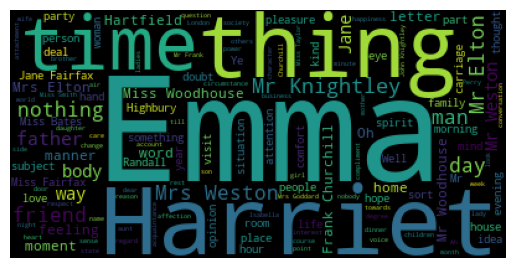

In [44]:
wordcloud = WordCloud()
wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

- 컬러맵 : https://matplotlib.org/stable/users/explain/colors/colormaps.html

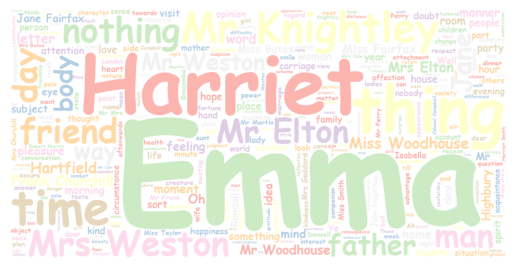

In [48]:
wordcloud = WordCloud(font_path='C:/Windows/Fonts/comicbd.ttf',
                     width=1200,  #생성될 이미지 가로(픽셀) 기본값은 400
                     height=600, #생성될 이미지 세로(픽셀) 기본값은 200 
                     background_color='white', #배경색
                     max_words=300, # 표시될 단어의 최대 갯수
                     relative_scaling=0.9, # 단어 빈도에 따른 크기 차이
                     colormap='Pastel1', # 글씨색상들(컬러맵)
#                      max_font_size=80, #최대 폰트 사이즈(픽셀)
#                      min_font_size=10  #최소 폰트 사이즈
                     ) 

wordcloud.generate(emma_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [49]:
# 생성된 wordcloud 저장
wordcloud.to_file('emma.jpg') # jpg나 png

In [55]:
#한글 말뭉치 kolaw_data
from konlpy.tag import Hannanum, Kkma, Komoran, Okt
from mecab  import MeCab
from nltk  import FreqDist
import pandas as pd

analyzer = MeCab()
noun_list = analyzer.nouns(kolaw_data)
noun_list = [word for word, tag in analyzer.pos(kolaw_data) if tag in ('NNG','NNp')]
noun_wordcount = FreqDist(noun_list)
wordCnt = pd.Series(noun_wordcount)
wordCnt.sort_values(ascending=False, inplace=True)
wordCnt.head(10)

법률     121
대통령     84
조       79
국가      73
헌법      69
국민      69
국회      69
때       55
필요      31
위원      30
dtype: int64

In [57]:
# 워드 클라우드에서 필요한 text
data_noun = ' '.join(noun_list)
data_noun[:100]

'헌법 역사 전통 국민 운동 건립 임시 정부 법통 불의 항거 민주 이념 계승 조국 민주 개혁 평화 통일 사명 입각 정의 동포 애 민족 단결 사회 폐습 불의 타파 자율 조화 바탕 자유'

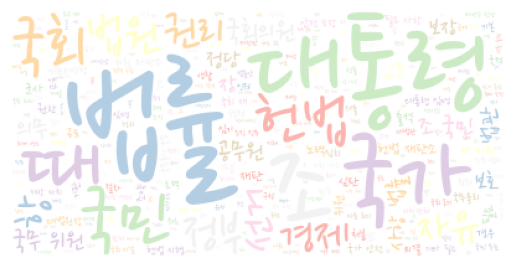

In [58]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white',
                max_words=300,
                colormap='Pastel1',
                
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [59]:
# 불용어 처리
from wordcloud import STOPWORDS
from nltk.corpus import stopwords
print('라이브러리에 등록된 불용어 언어들:',stopwords,fileids())
불용어 = stopwords.words('english')
print(불용어)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

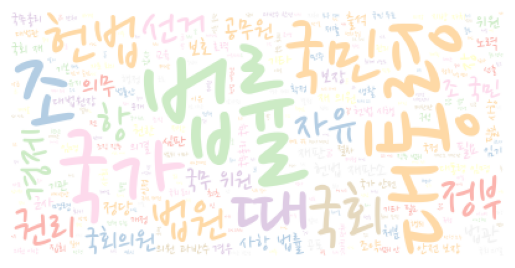

In [60]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white',
                max_words=300,
                colormap='Pastel1',
                stopwords=불용어,
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

(1600, 1600, 3) <class 'numpy.ndarray'>


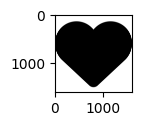

In [62]:
# 워드클라우드의 mask가 될 이미지->numpy 배열
# 이미지를 넘파이 배열로 방법1
import cv2
mask = cv2.imread('data/heart.jpg')
plt.figure(figsize=(1,1))
plt.imshow(mask)
print(mask.shape, type(mask))

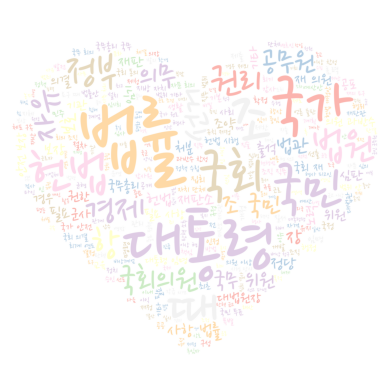

In [76]:
# 이미지를 넘파이 배열로 방법2

wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white',
                max_words=300,
                colormap='Pastel1',
                stopwords=불용어,
                mask=mask
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

((241, 257, 3), dtype('uint8'))

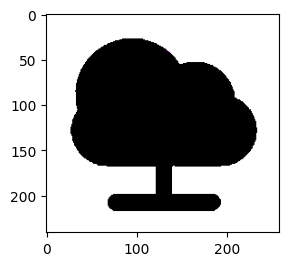

In [79]:
# mask2 = cv2,imread('data/test2.jpg')
# plt.figure(figsize=(3,3))
img = Image.open('data/test2.jpg')
mask2 = np.array(img)
plt.figure(figsize=(3,3))

mask2 = np.where(mask2>200,255,0).astype(np.uint8)
plt.imshow(mask2)
mask2.shape,mask2.dtype

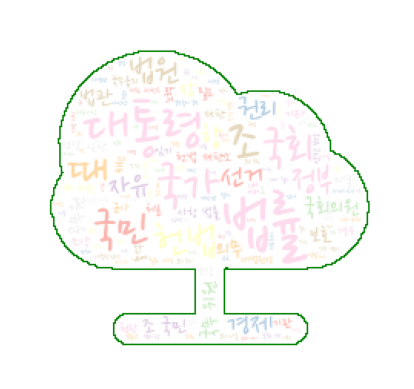

In [80]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white',
                max_words=300,
                colormap='Pastel1',
                stopwords=불용어,
                mask=mask2,
                contour_width=1,
                contour_color='green'
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

((1124, 720, 3), dtype('uint8'))

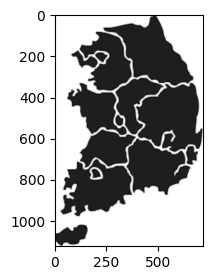

In [83]:
img = Image.open('data/south_korea.png').convert('RGB')
mask2 = np.array(img)
plt.figure(figsize=(3,3))

mask2 = np.array(img)  #.astype(np.uint8)
plt.imshow(mask2)
mask2.shape,mask2.dtype

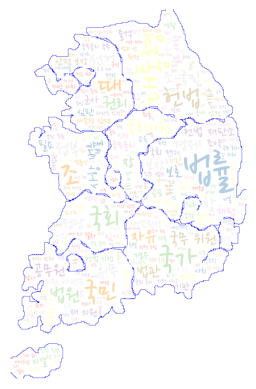

In [85]:
wordcloud = WordCloud(
                font_path='data/NanumPenScript-Regular.ttf',
                background_color='white',
                max_words=300,
                colormap='Pastel1',
                stopwords=불용어,
                mask=mask2,
                contour_width=1,
                contour_color='blue'
)
wordcloud.generate(data_noun)
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

## 단어의 빈도수 시각화

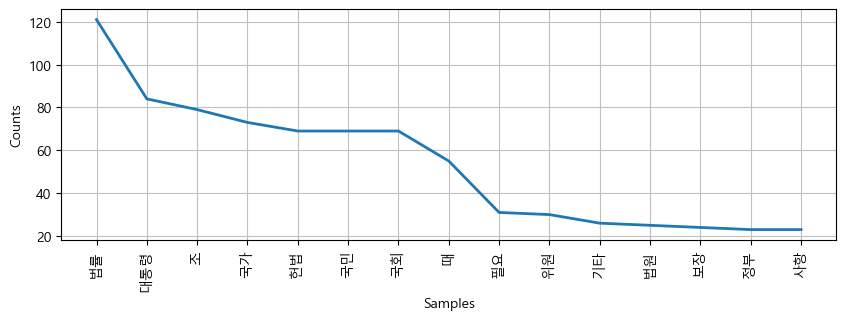

In [89]:

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus']=False
plt.rcParams['figure.figsize']=(20,4)

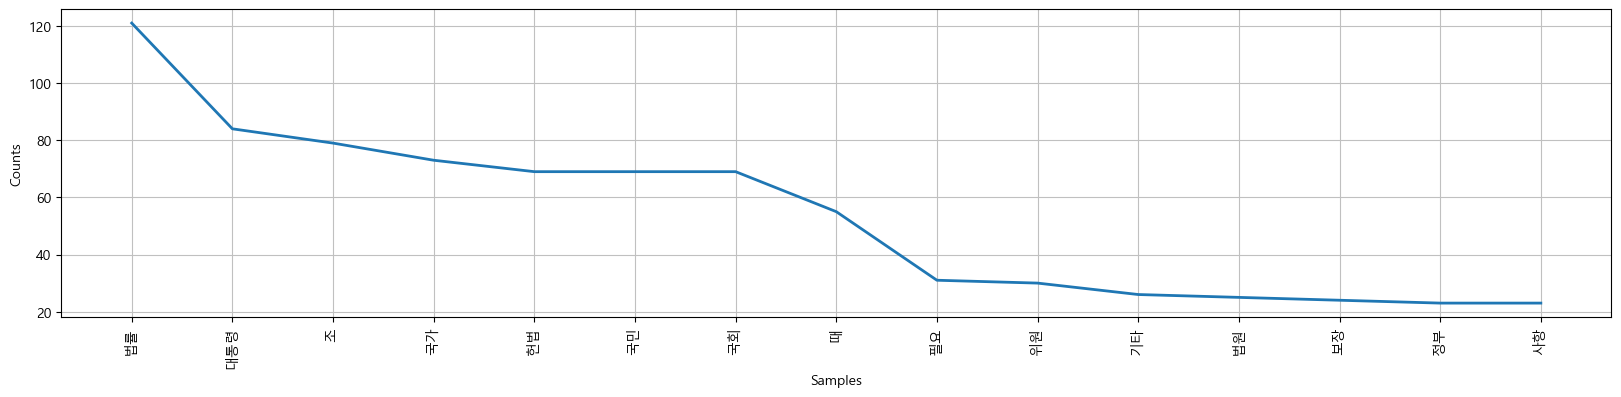

<Axes: xlabel='Samples', ylabel='Counts'>

In [91]:
from nltk import Text
data_text = Text(noun_list)
data_text.plot(15)

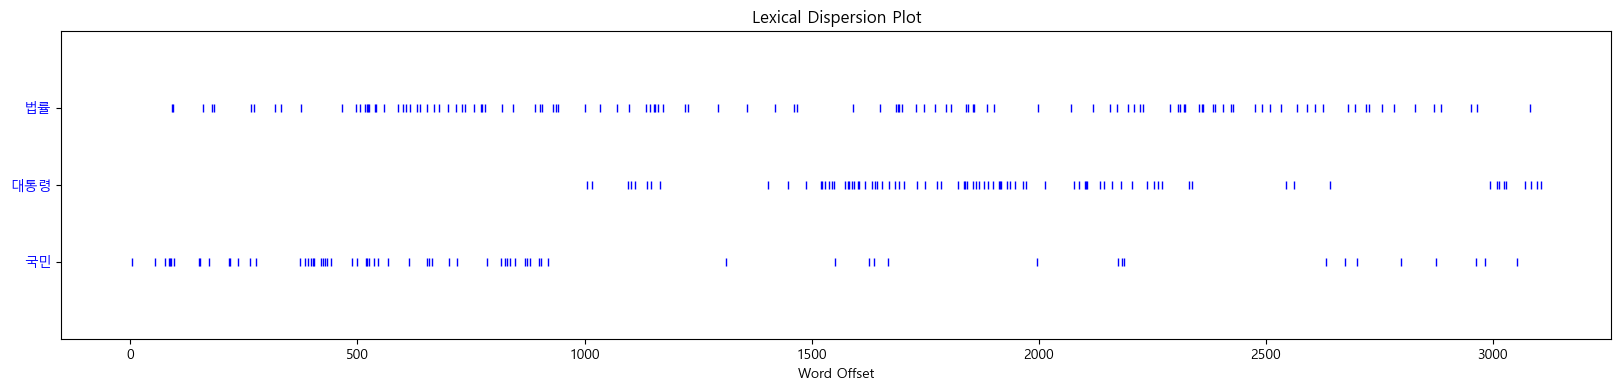

In [90]:
data_text.dispersion_plot(['법률','대통령','국민'])

# 6. 워드 임베딩
- 단어간 백터 계산
- Words2vec은 주변 같이 나오는 단어는 의미가 유사하는 아이디어로 단어를 숫자 좌표로 바꿔서 계산

- 경제뉴스 20개를 각각 병사만 가져와서 list(naver API)->워드 임배딩(단어간 거리계산)
    ```
        [['단어1','단어2','단어3',....],
         ['단어4','단어5','단어6',....],
         ['단어2','단어7','단어1',....]...]
    ```

In [94]:
# .env 가져오기(방법1) - 강추
from dotenv import load_dotenv
import os
load_dotenv()
# print(os.getenv('CLIENT_ID'))
# print(os.getenv('CLIENT_SECRET'))

True

In [95]:
# .env 가져오기(방법2) - 주피터 환경에서 안될수도있음
from decouple import config


In [100]:
import os
import requests
import json
import pandas as pd
client_id = os.getenv('CLIENT_ID')
client_secret = os.getenv('CLIENT_SECRET')

url = f"https://openapi.naver.com/v1/search/news.json" # JSON 결과
params = {'query':'스포츠', 'display':20 ,'sort':'date'}
headers = {
    'X-Naver-Client-Id': client_id,
    'X-Naver-Client-Secret':client_secret
}
response = requests.get(url, params=params, headers=headers)

items = response.json()['items'] # response를 json형태로 변환한것 중 'items'

items
# 제목(title)+' '+요약(description) 텍스만 추출하여 list
news_texts=[]
for item in items:
    title = item.get('title').replace('<b>',' ').replace('</b>',' ')
    description = item.get('description').replace('<b>',' ').replace('</b>',' ')
    news_texts.append(title+' '+description)
news_texts[:3],len(news_texts
                  )

['[건강 칼럼]사타구니·허벅지 통증 지속된다면? ‘고관절충돌증후군’...  스포츠  활동이나 반복적인 고관절 굴곡·회전 동작은 증상이 드러나거나 악화되는 계기가 될 수 있다. 진단은 증상과 진찰을 바탕으로 진행하며, 단순 방사선 촬영으로 뼈 형태와 관절염 여부를 확인하고 필요에 따라 MRI·CT... ',
 "신형 메르세데스-마이바흐 S클래스 '반얀트리 서울' 전시 통합 로열티 멤버십 '클럽한성을 중심으로 골프와  스포츠 , 문화·예술, 여가 등 고객의 취향과 라이프스타일을 반영한 프로그램을 운영하고, 럭셔리 브랜드 및 프리미엄 라이프스타일 파트너와의 협업을 통해 전시장... ",
 '알펜시아 스키 점프대 역주행하는 2026 레드불400 평창 대회 개최 이번 대회는 2018 평창동계올림픽 유산 시설인 알펜시아 스키점프대를 활용한 이색  스포츠  이벤트로 2019년 국내 최초로 평창에서 개최됐다. 이후 2024년과 2025년 대회도 성공적으로 개최하며 전국  스포츠 인들의... ']

In [104]:
# 명사추출
from konlpy.tag import Hannanum, Kkma, Komoran,Okt
from mecab import MeCab
analyzer = MeCab()
news = []
for article in news_texts:
    noun_list = analyzer.nouns(article)
    noun_list = [word for word,tag in analyzer.pos(article) if tag in('NNG','NNP')]
    news.append(noun_list)
print(news)

[['건강', '칼럼', '사타구니', '허벅지', '통증', '지속', '관절', '충돌', '증후군', '스포츠', '활동', '반복', '고관절', '굴곡', '회전', '동작', '증상', '악화', '계기', '진단', '증상', '진찰', '바탕', '진행', '단순', '방사선', '촬영', '뼈', '형태', '관절염', '여부', '확인', '필요'], ['신형', '메르세데스', '마이바흐', '클래스', '반', '얀', '트리', '서울', '전시', '통합', '로열티', '멤버십', '클럽', '성', '중심', '골프', '스포츠', '문화', '예술', '여가', '고객', '취향', '라이프', '스타일', '반영', '프로그램', '운영', '브랜드', '프리미엄', '라이프', '스타일', '파트너', '협업', '시장'], ['알펜시아', '스키', '점프대', '역주행', '레드불', '창', '대회', '개최', '이번', '대회', '평창동', '올림픽', '유산', '시설', '알펜시아', '스키', '점프대', '활용', '이색', '스포츠', '이벤트', '국내', '최초', '평창', '개최', '이후', '대회', '성공', '개최', '전국', '스포츠', '인'], ['곽', '시양', '유지애', '부부', '결혼', '공식', '입장', '사랑', '매력', '보컬', '각종', '참여', '보컬리스트', '존재감', '입증', '예능', '콘텐츠', '예', '능감', '차세대', '예능', '돌', '면모', '발휘', '손진아', '스포츠', '기자'], ['스페셜', '올림픽', '코리아', '전국', '하계', '대회', '제니', '우스', '스포츠', '메달', '탁', '구단', '성적', '최선', '한편', '제니', '우스', '스포츠', '단', '장애', '생활', '체육', '활성', '선수', '경기력', '향상', '훈련', '각종', '전국', '대회', '지역', '대회'

In [107]:
# 워드 임베일(단어간 거리 계산)
from gensim.models import Word2Vec
model = Word2Vec(news, # 2차원 학습데이터
                 window=15, # 각 단어의 좌우15개 단어를 학습컨텐츠로 사용 
                 min_count=2, # 2회이상 등장한 단어만 학습
                 workers=-1,  #병렬처리 core갯수(-1:모든 기용 core 다 사용)
                 sg=1) # 소량데이터에서의 학습방식 / 대량 데이터에서는 0

In [109]:
# 학습한 단어 리스트
print(model.wv.index_to_key)

['스포츠', '대회', '시장', '지역', '브랜드', '롤러', '한국', '경기', '장애', '청년', '프로', '트럼프', '대상', '모델', '지원', '기자', '시양', '곽', '전국', '준비', '자립', '평택', '컵', '프레지', '수출', '포도', '김천', '맥주', '배우', '투데이', '미국', '대전', '연맹', '경상북도', '남자', '확대', '차', '수입', '레저', '해외', '스지', '체육', '올림픽', '이번', '개최', '프로그램', '골프', '확인', '진행', '통증', '건강', '감소', '인구', '유치', '최원용', '대만', '동아', '영조', 'ㅣ', '작품', '서예', '경북', '보도', '국제', '논란', '조작', '문의', '대사관', '제작진', '카스', '대통령', '바네사', '이날', '운전', '우즈', '안동시', '반부', '팀', '등록', '대표', '판매', '시청', '광주', '강화', '광주시', '관리', '완화', '뒤', '기반', '발간', '보고서', '경영', '국민체육진흥공단', '선수', '구단', '우스', '제니', '콘텐츠', '예능', '각종', '사랑', '결혼', '유지애', '국내', '활용', '점프대', '스키', '알펜시아', '협업', '스타일', '라이프', '예술', '문화', '성', '서울', '필요', '여부', '증상', '활동']


In [111]:
# 유사도가 높은 단어
model.wv.most_similar('대회',topn=10)

[('맥주', 0.18890605866909027),
 ('컵', 0.18855659663677216),
 ('감소', 0.18359005451202393),
 ('유지애', 0.18345922231674194),
 ('제니', 0.17804878950119019),
 ('지원', 0.16072483360767365),
 ('안동시', 0.15974180400371552),
 ('전국', 0.15923377871513367),
 ('대사관', 0.15861040353775024),
 ('활용', 0.15196380019187927)]

In [112]:
# 단어를 입력받아 유사한 단어 5개를 출력하기
word = input('유사도를 알고 싶은 단어는?')

print(model.wv.most_similar(word,topn=5))

유사도를 알고 싶은 단어는?프로
[('이번', 0.26858505606651306), ('필요', 0.20910833775997162), ('우즈', 0.15416142344474792), ('확대', 0.14284475147724152), ('문의', 0.12990374863147736)]
